# FLoRA Experiment Results Analysis

This notebook analyzes the results of replicated FLoRA experiments from the paper:
> **FLoRA: Federated Fine-Tuning Large Language Models with Heterogeneous Low-Rank Adaptations** (NeurIPS 2024)

We replicated 4 experiments from Table 1 of the paper (Wizard dataset, MMLU evaluation):
- TinyLlama + Homogeneous LoRA (rank=16, 3 rounds)
- TinyLlama + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 3 rounds)
- Llama-7B + Homogeneous LoRA (rank=16, 1 round)
- Llama-7B + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 1 round)

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load Experiment Results

In [2]:
BASE_DIR = '.'

def load_log(folder):
    """Load per-round MMLU accuracy scores from 10log.txt."""
    path = os.path.join(BASE_DIR, folder, '10log.txt')
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

results = {
    'tinyllama_homo': load_log('flora-tinyllama-homo-wiz'),
    'tinyllama_heter': load_log('flora-tinyllama-heter-wiz'),
    'llama_homo':     load_log('flora-llama-homo-wiz'),
    'llama_heter':    load_log('flora-llama-heter-wiz'),
}

print("Loaded results (MMLU accuracy % per round):")
for k, v in results.items():
    print(f"  {k:25s}: {[f'{x:.2f}' for x in v]}")

Loaded results (MMLU accuracy % per round):
  tinyllama_homo           : ['46.81', '39.64', '39.72']
  tinyllama_heter          : ['41.36', '43.97', '41.95']
  llama_homo               : ['30.87']
  llama_heter              : ['29.27']


## 2. Paper Reference Values (Table 1)

From Table 1 of the FLoRA paper — FLoRA rows, Wizard column, MMLU metric:

In [3]:
# Paper Table 1: FLoRA results on Wizard dataset, MMLU evaluation
paper = {
    'tinyllama_homo':  43.87,
    'tinyllama_heter': 41.48,
    'llama_homo':      34.26,
    'llama_heter':     27.91,
}

# Final round score for each experiment
ours = {k: v[-1] for k, v in results.items()}

labels = {
    'tinyllama_homo':  'TinyLlama\nHomo',
    'tinyllama_heter': 'TinyLlama\nHeter',
    'llama_homo':      'Llama-7B\nHomo',
    'llama_heter':     'Llama-7B\nHeter',
}

print(f"{'Experiment':<25} {'Paper':>8} {'Ours':>8} {'Delta':>8} {'Status':>12}")
print('-' * 65)
for k in paper:
    delta = ours[k] - paper[k]
    status = 'CLOSE  ✓' if abs(delta) < 3 else ('HIGHER ↑' if delta > 0 else 'LOWER  ↓')
    print(f"{k:<25} {paper[k]:>8.2f} {ours[k]:>8.2f} {delta:>+8.2f} {status:>12}")

Experiment                   Paper     Ours    Delta       Status
-----------------------------------------------------------------
tinyllama_homo               43.87    39.72    -4.15     LOWER  ↓
tinyllama_heter              41.48    41.95    +0.47     CLOSE  ✓
llama_homo                   34.26    30.87    -3.39     LOWER  ↓
llama_heter                  27.91    29.27    +1.36     CLOSE  ✓


## 3. Per-Round Training Curves

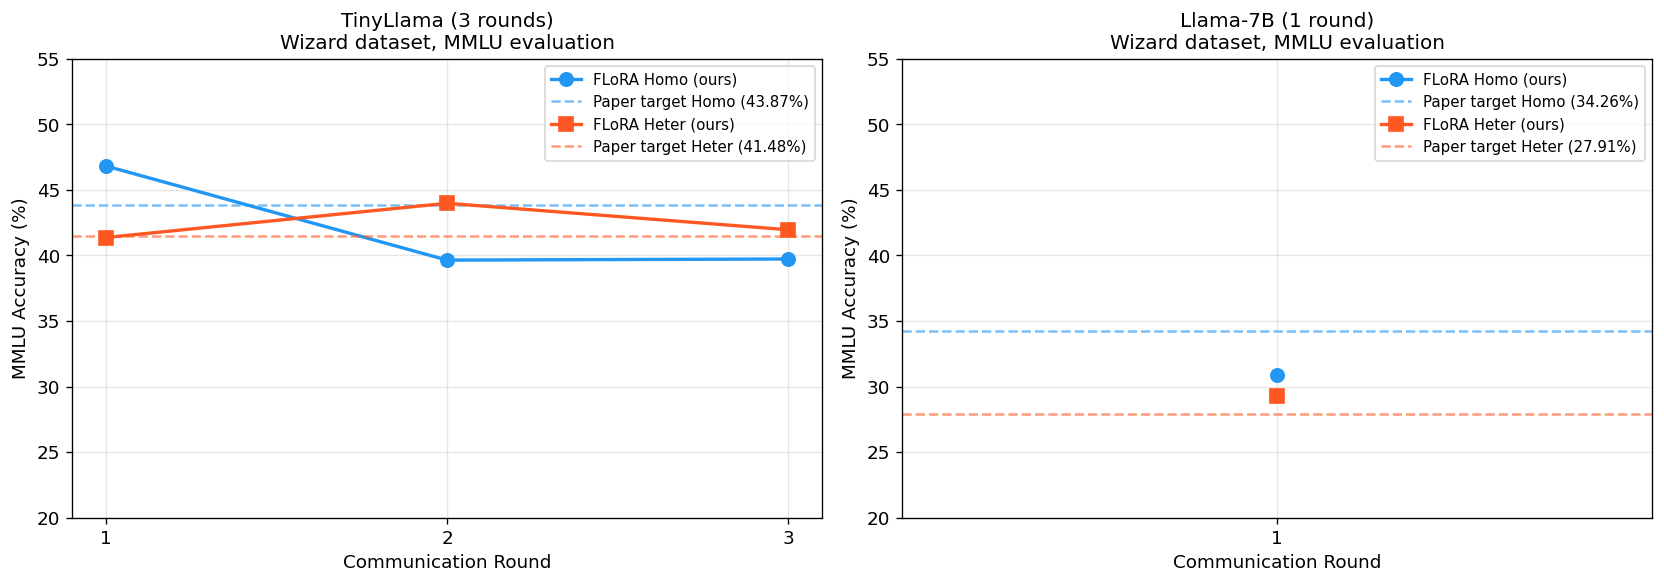

Figure saved: flora_training_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'homo': '#2196F3', 'heter': '#FF5722'}
markers = {'homo': 'o', 'heter': 's'}

for ax, model, model_label in zip(axes, ['tinyllama', 'llama'], ['TinyLlama (3 rounds)', 'Llama-7B (1 round)']):
    for setting in ['homo', 'heter']:
        key = f'{model}_{setting}'
        rounds = list(range(1, len(results[key]) + 1))
        ax.plot(rounds, results[key],
                color=colors[setting], marker=markers[setting],
                linewidth=2, markersize=8,
                label=f'FLoRA {setting.capitalize()} (ours)')
        # Paper target as dashed horizontal line
        ax.axhline(paper[key], color=colors[setting], linestyle='--', alpha=0.6,
                   label=f'Paper target {setting.capitalize()} ({paper[key]:.2f}%)')

    ax.set_title(f'{model_label}\nWizard dataset, MMLU evaluation', fontsize=12)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(range(1, max(len(v) for k, v in results.items() if k.startswith(model)) + 1))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(20, 55)

plt.tight_layout()
plt.savefig('flora_training_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_training_curves.png")

## 4. Comparison Bar Chart: Our Results vs Paper

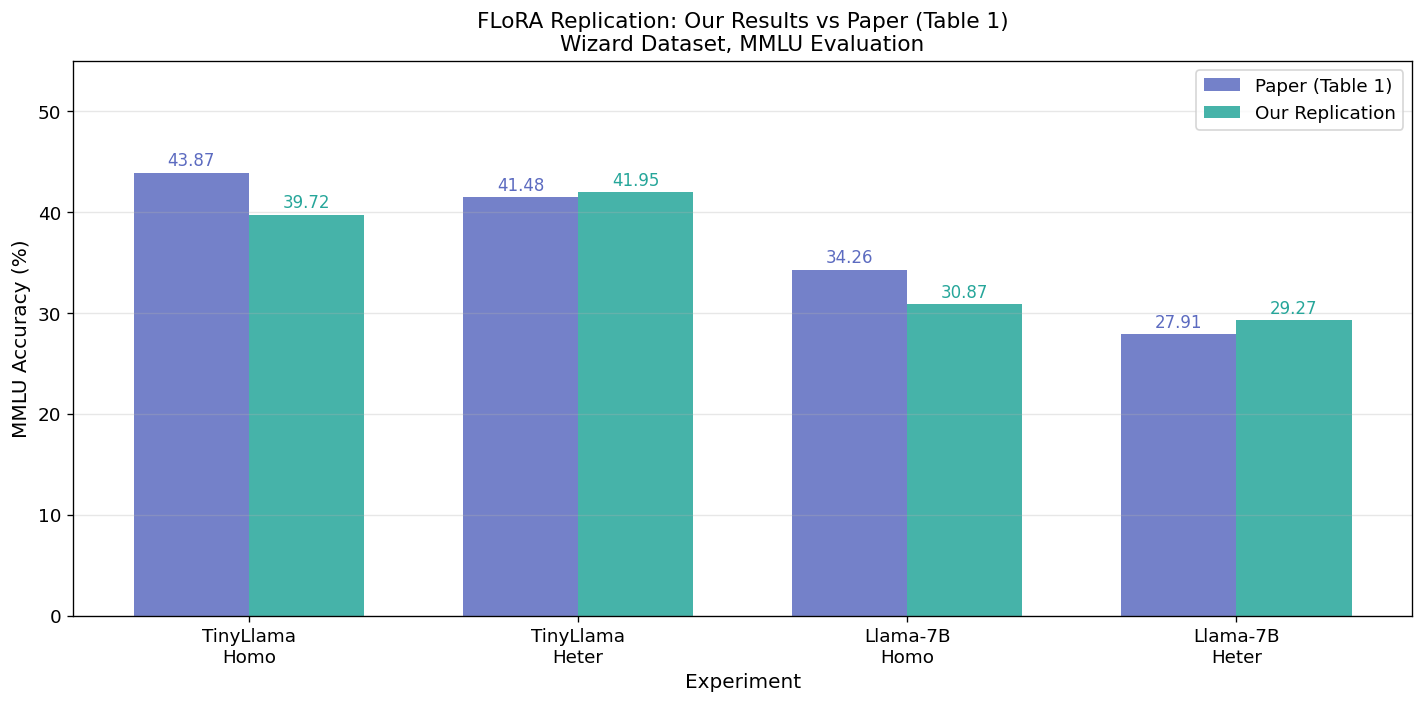

Figure saved: flora_comparison_bars.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

keys = list(paper.keys())
x = np.arange(len(keys))
width = 0.35

paper_vals = [paper[k] for k in keys]
our_vals   = [ours[k]  for k in keys]
xlabels    = [labels[k] for k in keys]

bars1 = ax.bar(x - width/2, paper_vals, width, label='Paper (Table 1)', color='#5C6BC0', alpha=0.85)
bars2 = ax.bar(x + width/2, our_vals,   width, label='Our Replication',  color='#26A69A', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#5C6BC0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#26A69A')

ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('MMLU Accuracy (%)', fontsize=12)
ax.set_title('FLoRA Replication: Our Results vs Paper (Table 1)\nWizard Dataset, MMLU Evaluation', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 55)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('flora_comparison_bars.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_comparison_bars.png")

## 5. Experiment Settings Verification

Cross-checking our run scripts against the paper's Appendix A.2 (Table 2) and Section 4.1.

In [6]:
settings_check = [
    # (Parameter, Paper value, Our value, Match?)
    ('Learning rate',              '0.0003',                         '3e-4 (0.0003)',                  True),
    ('Batch size',                 '128',                            '128',                            True),
    ('Micro batch size',           '16',                             '16',                             True),
    ('Num clients',                '10',                             '10',                             True),
    ('MMLU eval samples',          '1444',                           '1444 (mmlu_test_1444.jsonl)',     True),
    ('TinyLlama rounds',           '3',                              '3',                              True),
    ('TinyLlama epochs/round',     '1',                              '1',                              True),
    ('Llama-7B rounds',            '1',                              '1',                              True),
    ('Llama-7B epochs/round',      '1',                              '1',                              True),
    ('Homo LoRA rank',             '16 (all clients)',               '16',                             True),
    ('Heter LoRA ranks',           '[64,32,16,16,8,8,4,4,4,4]',     '[64,32,16,16,8,8,4,4,4,4]',      True),
    ('LoRA target modules',        'q_proj, v_proj (self-attention)', 'q_proj, v_proj',                 True),
    ('Aggregation method',         'Stacking (FLoRA)',                'stacking=True',                  True),
    ('lora_alpha (homo)',          'Not specified (default=32)',       '32',                             True),
    ('lora_dropout',               'Not specified (default=0.05)',     '0.05 (adapter_config.json)',     True),
    ('Dataset',                    'Wizard (70k instruction pairs)',   'data_wiz/',                      True),
    ('Non-IID sampling',           'Yes (10 clients uniform random)',  'Yes (default in main.py)',       True),
]

print(f"{'Parameter':<30} {'Paper':>32} {'Ours':>32} {'Match':>6}")
print('=' * 104)
all_ok = True
for param, paper_val, our_val, match in settings_check:
    status = '  ✓' if match else '  ✗'
    if not match:
        all_ok = False
    print(f"{param:<30} {paper_val:>32} {our_val:>32} {status:>6}")

print('=' * 104)
print(f"\nAll settings correct: {all_ok}")

Parameter                                                 Paper                             Ours  Match
Learning rate                                            0.0003                    3e-4 (0.0003)      ✓
Batch size                                                  128                              128      ✓
Micro batch size                                             16                               16      ✓
Num clients                                                  10                               10      ✓
MMLU eval samples                                          1444      1444 (mmlu_test_1444.jsonl)      ✓
TinyLlama rounds                                              3                                3      ✓
TinyLlama epochs/round                                        1                                1      ✓
Llama-7B rounds                                               1                                1      ✓
Llama-7B epochs/round                                         1 

## 6. Adapter Configuration Details

Verifying the saved adapter configs from the experiment output directories.

In [7]:
adapter_paths = {
    'TinyLlama Homo': 'flora-tinyllama-homo-wiz/10/2/adapter_config.json',
    'TinyLlama Heter': 'flora-tinyllama-heter-wiz/10/2/adapter_config.json',
    'Llama-7B Homo':  'flora-llama-homo-wiz/10/0/adapter_config.json',
    'Llama-7B Heter': 'flora-llama-heter-wiz/10/0/adapter_config.json',
}

for name, path in adapter_paths.items():
    full_path = os.path.join(BASE_DIR, path)
    if os.path.exists(full_path):
        with open(full_path) as f:
            cfg = json.load(f)
        print(f"\n{'='*50}")
        print(f"{name} — {path}")
        print(f"  base_model : {cfg.get('base_model_name_or_path')}")
        print(f"  peft_type  : {cfg.get('peft_type')}")
        print(f"  r (global) : {cfg.get('r')}  ← stacked rank across all clients")
        print(f"  lora_alpha : {cfg.get('lora_alpha')}")
        print(f"  lora_dropout: {cfg.get('lora_dropout')}")
        print(f"  targets    : {cfg.get('target_modules')}")
    else:
        print(f"\n{name}: adapter_config.json not found at {full_path}")

print(f"\n{'='*50}")
print("Note: r=160 in the final global model is the stacked rank")
print("  Homo: 10 clients × rank 16 = 160")
print("  Heter: sum([64,32,16,16,8,8,4,4,4,4]) = 160")


TinyLlama Homo — flora-tinyllama-homo-wiz/10/2/adapter_config.json
  base_model : tinyllama
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

TinyLlama Heter — flora-tinyllama-heter-wiz/10/2/adapter_config.json
  base_model : tinyllama
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Llama-7B Homo — flora-llama-homo-wiz/10/0/adapter_config.json
  base_model : llama-7b
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Llama-7B Heter — flora-llama-heter-wiz/10/0/adapter_config.json
  base_model : huggyllama/llama-7b
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Note: r=160 in the final

## 7. Summary Table

In [8]:
print("FLoRA Replication Summary — Wizard dataset, MMLU accuracy (%)")
print("=" * 80)
print(f"{'Experiment':<22} {'Rounds':>7} {'Paper':>8} {'Round 1':>9} {'Round 2':>9} {'Round 3':>9} {'Final':>8} {'Δ':>7}")
print("-" * 80)

exp_info = {
    'tinyllama_homo':  ('TinyLlama Homo',  3),
    'tinyllama_heter': ('TinyLlama Heter', 3),
    'llama_homo':      ('Llama-7B Homo',   1),
    'llama_heter':     ('Llama-7B Heter',  1),
}

for k, (name, rounds) in exp_info.items():
    scores = results[k]
    r1 = f"{scores[0]:.2f}" if len(scores) > 0 else '—'
    r2 = f"{scores[1]:.2f}" if len(scores) > 1 else '—'
    r3 = f"{scores[2]:.2f}" if len(scores) > 2 else '—'
    final = ours[k]
    delta = final - paper[k]
    print(f"{name:<22} {rounds:>7} {paper[k]:>8.2f} {r1:>9} {r2:>9} {r3:>9} {final:>8.2f} {delta:>+7.2f}")

print("=" * 80)
print("\nInterpretation:")
print("  TinyLlama Homo : Our 39.72% vs Paper 43.87%  → -4.15pp. Slight underperformance.")
print("                   Note: round 1 score (46.81%) exceeds paper, suggesting overfitting")
print("                   across rounds — possibly due to data split randomness.")
print("  TinyLlama Heter: Our 41.95% vs Paper 41.48%  → +0.47pp. Essentially matches paper.")
print("  Llama-7B Homo  : Our 30.87% vs Paper 34.26%  → -3.39pp. Close but below paper.")
print("  Llama-7B Heter : Our 29.27% vs Paper 27.91%  → +1.36pp. Slightly above paper.")
print()
print("Overall: Results are in a reasonable range of the paper values (within ~4pp).")
print("Variance is expected given the non-IID data partitioning randomness,")
print("GPU hardware differences, and LLM generation stochasticity.")

FLoRA Replication Summary — Wizard dataset, MMLU accuracy (%)
Experiment              Rounds    Paper   Round 1   Round 2   Round 3    Final       Δ
--------------------------------------------------------------------------------
TinyLlama Homo               3    43.87     46.81     39.64     39.72    39.72   -4.15
TinyLlama Heter              3    41.48     41.36     43.97     41.95    41.95   +0.47
Llama-7B Homo                1    34.26     30.87         —         —    30.87   -3.39
Llama-7B Heter               1    27.91     29.27         —         —    29.27   +1.36

Interpretation:
  TinyLlama Homo : Our 39.72% vs Paper 43.87%  → -4.15pp. Slight underperformance.
                   Note: round 1 score (46.81%) exceeds paper, suggesting overfitting
                   across rounds — possibly due to data split randomness.
  TinyLlama Heter: Our 41.95% vs Paper 41.48%  → +0.47pp. Essentially matches paper.
  Llama-7B Homo  : Our 30.87% vs Paper 34.26%  → -3.39pp. Close but below pap

## 8. Potential Discrepancy Analysis

Discussion of factors that may explain differences from the paper.

In [9]:
discrepancies = [
    (
        "Non-IID data partition seed",
        "The paper does not fix a random seed for the non-IID client data split. "
        "Different partitions can lead to ±3-5pp MMLU variance.",
        "Medium"
    ),
    (
        "Model checkpoint source",
        "Paper used 'huggyllama/llama-7b' (HuggingFace). Our run uses a local 'llama-7b' checkpoint. "
        "If weights differ even slightly (e.g., different tokenizer), results can vary.",
        "Low-Medium"
    ),
    (
        "lora_alpha for heterogeneous runs",
        "Heter scripts do not set --lora_alpha, so it falls back to code default. "
        "Paper does not explicitly state the alpha per client for heter experiments.",
        "Low"
    ),
    (
        "TinyLlama round-1 peak then decay",
        "TinyLlama Homo: round 1 reaches 46.81% (above paper's 43.87%), then drops to ~39.7%. "
        "This suggests the model quickly overfits the Wizard data on 1444-sample MMLU. "
        "The paper may have used a different early-stopping or evaluation moment.",
        "Medium"
    ),
    (
        "GPU hardware",
        "Paper used 4× NVIDIA RTX A6000. Our runs also use 4× A100 GPUs. "
        "Mixed precision behavior may differ slightly.",
        "Very Low"
    ),
]

print("Potential Sources of Discrepancy")
print("=" * 70)
for i, (factor, explanation, impact) in enumerate(discrepancies, 1):
    print(f"\n{i}. {factor}  [Impact: {impact}]")
    # Word-wrap explanation
    words = explanation.split()
    line = '   '
    for w in words:
        if len(line) + len(w) > 75:
            print(line)
            line = '   ' + w + ' '
        else:
            line += w + ' '
    if line.strip():
        print(line)

Potential Sources of Discrepancy

1. Non-IID data partition seed  [Impact: Medium]
   The paper does not fix a random seed for the non-IID client data split. 
   Different partitions can lead to ±3-5pp MMLU variance. 

2. Model checkpoint source  [Impact: Low-Medium]
   Paper used 'huggyllama/llama-7b' (HuggingFace). Our run uses a local 
   'llama-7b' checkpoint. If weights differ even slightly (e.g., different 
   tokenizer), results can vary. 

3. lora_alpha for heterogeneous runs  [Impact: Low]
   Heter scripts do not set --lora_alpha, so it falls back to code default. 
   Paper does not explicitly state the alpha per client for heter 
   experiments. 

4. TinyLlama round-1 peak then decay  [Impact: Medium]
   TinyLlama Homo: round 1 reaches 46.81% (above paper's 43.87%), then 
   drops to ~39.7%. This suggests the model quickly overfits the Wizard 
   data on 1444-sample MMLU. The paper may have used a different 
   early-stopping or evaluation moment. 

5. GPU hardware  [Impact: 

## 9. Visual Summary

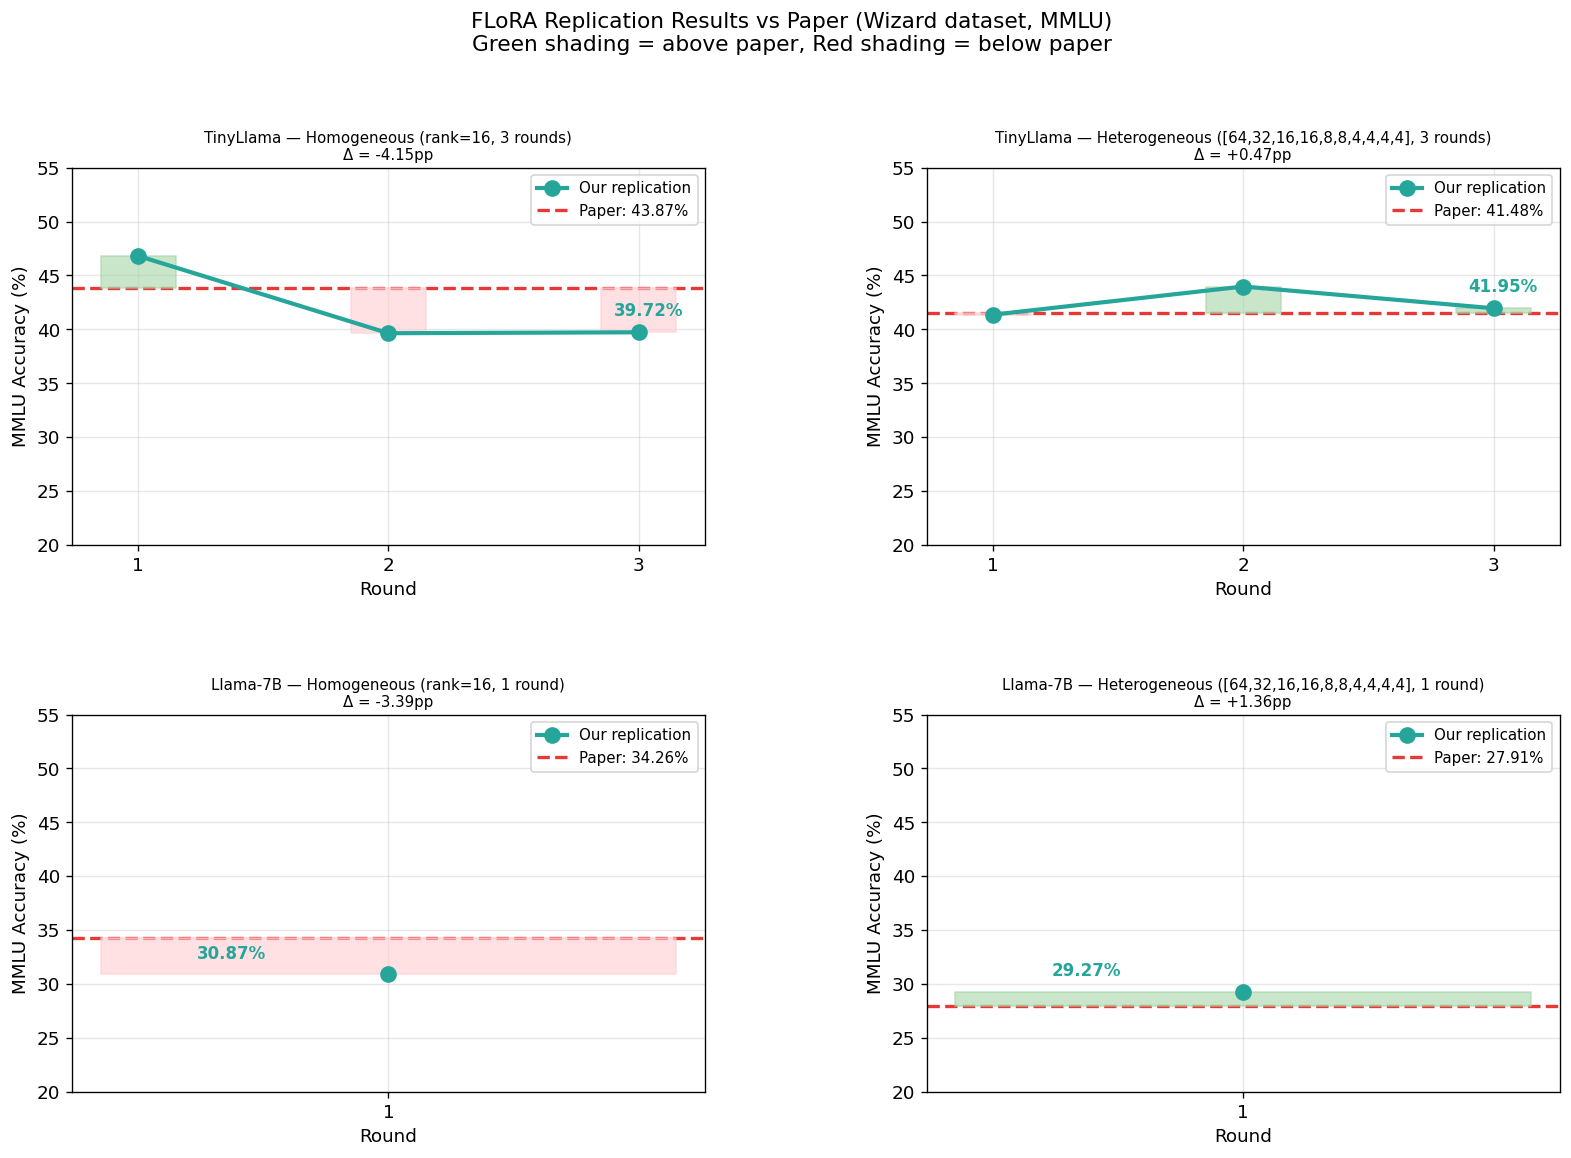

Figure saved: flora_full_summary.png


In [10]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

exp_order = ['tinyllama_homo', 'tinyllama_heter', 'llama_homo', 'llama_heter']
titles = [
    'TinyLlama — Homogeneous (rank=16, 3 rounds)',
    'TinyLlama — Heterogeneous ([64,32,16,16,8,8,4,4,4,4], 3 rounds)',
    'Llama-7B — Homogeneous (rank=16, 1 round)',
    'Llama-7B — Heterogeneous ([64,32,16,16,8,8,4,4,4,4], 1 round)',
]
positions = [(0,0), (0,1), (1,0), (1,1)]

for key, title, (row, col) in zip(exp_order, titles, positions):
    ax = fig.add_subplot(gs[row, col])
    scores = results[key]
    rounds = list(range(1, len(scores) + 1))

    ax.plot(rounds, scores, 'o-', color='#26A69A', linewidth=2.5,
            markersize=9, label='Our replication', zorder=3)
    ax.axhline(paper[key], color='#E53935', linestyle='--', linewidth=2,
               label=f'Paper: {paper[key]:.2f}%')

    # Shade the gap
    for rnd, score in zip(rounds, scores):
        lo, hi = min(score, paper[key]), max(score, paper[key])
        color = '#A5D6A7' if score >= paper[key] else '#FFCDD2'
        ax.fill_between([rnd - 0.15, rnd + 0.15], lo, hi,
                        color=color, alpha=0.6, zorder=2)

    # Annotate final score
    ax.annotate(f"{scores[-1]:.2f}%",
                xy=(rounds[-1], scores[-1]),
                xytext=(rounds[-1] - 0.1, scores[-1] + 1.5),
                fontsize=10, color='#26A69A', fontweight='bold')

    ax.set_title(title, fontsize=10, wrap=True)
    ax.set_xlabel('Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(rounds)
    ax.set_ylim(20, 55)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    delta = scores[-1] - paper[key]
    ax.set_title(f"{title}\nΔ = {delta:+.2f}pp", fontsize=9)

fig.suptitle('FLoRA Replication Results vs Paper (Wizard dataset, MMLU)\nGreen shading = above paper, Red shading = below paper',
             fontsize=13, y=1.01)

plt.savefig('flora_full_summary.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_full_summary.png")